<a href="https://colab.research.google.com/github/mukeshrock7897/Artificial-Intelligence-Notes/blob/main/2_Computer_Vision_Intermediate_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Intermediate Level**

1. Image Segmentation
    * Thresholding
    * Edge detection: Canny, Sobel
    * Contours detection and properties
    * Watershed algorithm

1. Feature Detection and Description
    * Harris corner detection
    * SIFT (Scale-Invariant Feature Transform)
    * SURF (Speeded-Up Robust Features)
    * ORB (Oriented FAST and Rotated BRIEF)

1. Image Stitching and Panorama Creation
    * Homography and warping
    * Image stitching pipeline
    * RANSAC algorithm

1. Object Detection
    * Haar Cascades
    * HOG (Histogram of Oriented Gradients) and SVM
    * YOLO (You Only Look Once)
    * SSD (Single Shot MultiBox Detector)

1. Face Detection and Recognition
    * Face detection with Haar Cascades and Dlib
    * Face landmarks detection
    * Face recognition with OpenCV and Dlib


# **1. Image Segmentation**

**Thresholding**

* Thresholding is a simple technique to segment an image by setting a threshold value. Pixels above the threshold are set to one value (e.g., white), and those below are set to another value (e.g., black).

**Example:**

In [22]:
import requests
# Download the image
url = 'https://www.color-hex.com/palettes/18912.png'
response = requests.get(url)
with open('/content/sample_data/example.jpg', 'wb') as f:
    f.write(response.content)

with open('/content/sample_data/example1.jpg', 'wb') as f:
    f.write(response.content)

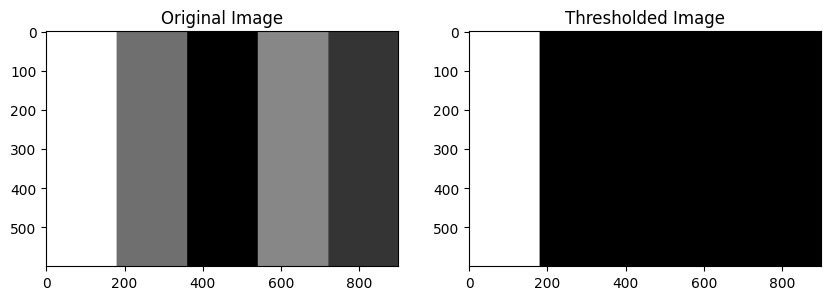

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale, make sure the path is correct
# If the image is in the same directory as the notebook, you can just use the filename
image = cv2.imread('/content/sample_data/example.jpg', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded correctly
if image is None:
    print("Error: Could not read the image. Please check the file path and ensure the image is not corrupted.")
else:
    # Apply global thresholding
    _, thresh_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    # Display the original and thresholded images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(thresh_image, cmap='gray')
    plt.title('Thresholded Image')

    plt.show()

**Edge Detection: Canny, Sobel**

* Edge detection identifies significant transitions in intensity in an image, highlighting object boundaries.

**Example (Canny):**



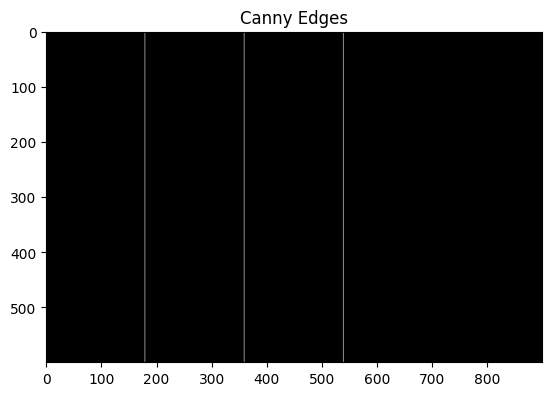

In [4]:
# Apply Canny edge detection
edges = cv2.Canny(image, 100, 200)

# Display the edges
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.show()


**Example (Sobel):**

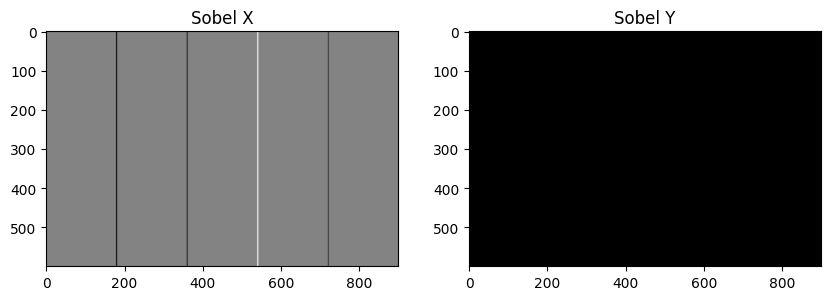

In [5]:
# Apply Sobel edge detection
sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)

# Display the Sobel edges
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sobelx, cmap='gray')
plt.title('Sobel X')

plt.subplot(1, 2, 2)
plt.imshow(sobely, cmap='gray')
plt.title('Sobel Y')

plt.show()


**Contours Detection and Properties**

* Contours represent the boundaries of objects in an image.

**Example:**



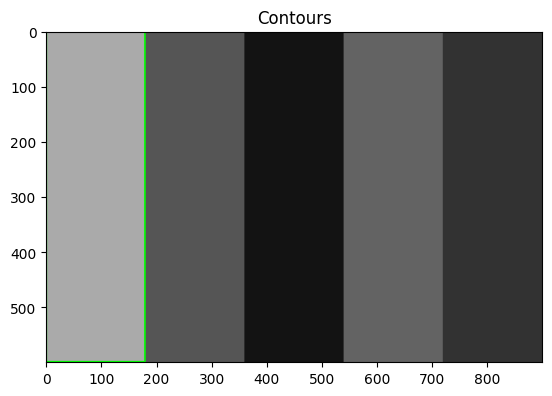

In [6]:
# Find contours
contours, _ = cv2.findContours(thresh_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
contour_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

# Display the image with contours
plt.imshow(contour_image)
plt.title('Contours')
plt.show()


**Watershed Algorithm**

* The Watershed algorithm is used to segment overlapping objects by treating grayscale images as topographic surfaces.

**Example:**

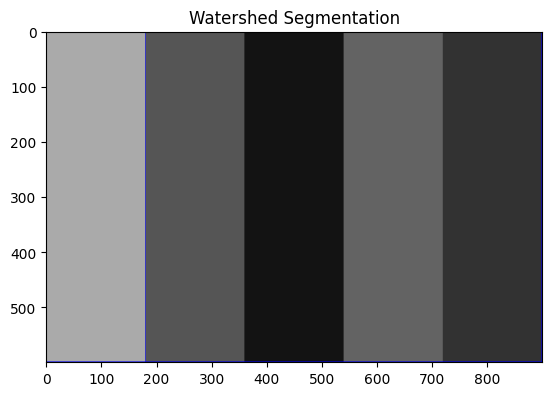

In [10]:
import cv2
import numpy as np # Import the NumPy library
import matplotlib.pyplot as plt

# Convert image to grayscale - removed as image is already grayscale
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Apply threshold
ret, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
# Remove noise
kernel = np.ones((3,3),np.uint8) # Now np is defined and can be used
opening = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel, iterations = 2)
# Sure background area
sure_bg = cv2.dilate(opening,kernel,iterations=3)
# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
ret, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)
# Marker labeling
ret, markers = cv2.connectedComponents(sure_fg)
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

# Convert markers to 32-bit signed integer single-channel image
markers = np.int32(markers)

# Convert image to 3-channel 8-bit unsigned integer image if it's grayscale
if image.ndim == 2:  # Check if the image is grayscale
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

markers = cv2.watershed(image,markers)
image[markers == -1] = [255,0,0]

# Display the segmented image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Watershed Segmentation')
plt.show()

# **2. Feature Detection and Description**

**Harris Corner Detection**

* The Harris Corner Detector is used to identify corners in an image.

**Example:**

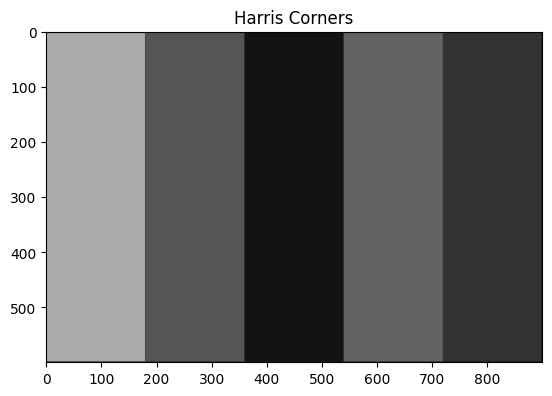

In [12]:
# Harris corner detection
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
gray = np.float32(gray)  # Convert to float32
harris_corners = cv2.cornerHarris(gray, 2, 3, 0.04)
# Mark corners in the image
image[harris_corners > 0.01 * harris_corners.max()] = [0, 0, 255]

# Display the image with corners
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners')
plt.show()

**SIFT (Scale-Invariant Feature Transform)**

* SIFT detects and describes local features in images.

**Example:**

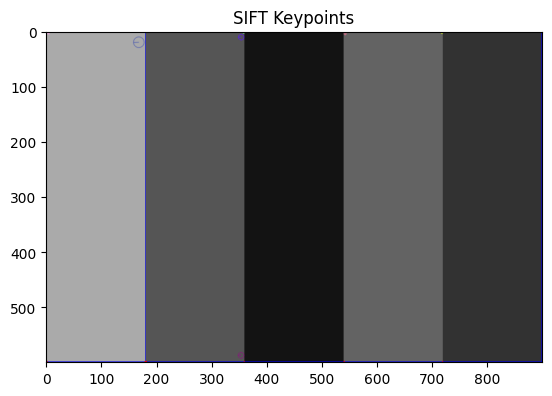

In [13]:
# Initialize the SIFT detector
sift = cv2.SIFT_create()

# Detect SIFT features
keypoints, descriptors = sift.detectAndCompute(image, None)

# Draw keypoints
sift_image = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints
plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.show()


**SURF (Speeded-Up Robust Features)**

* SURF is similar to SIFT but faster.

**Example:**

In [16]:
!pip uninstall opencv-python
!pip uninstall opencv-contrib-python

!sudo apt-get install build-essential cmake git libgtk2.0-dev pkg-config libavcodec-dev libavformat-dev libswscale-dev

!git clone https://github.com/opencv/opencv.git
!git clone https://github.com/opencv/opencv_contrib.git

# Initialize the SURF detector
surf = cv2.xfeatures2d.SURF_create(400)

# Detect SURF features
keypoints, descriptors = surf.detectAndCompute(image, None)

# Draw keypoints
surf_image = cv2.drawKeypoints(image, keypoints, None, (255, 0, 0), 4)

# Display the image with keypoints
plt.imshow(cv2.cvtColor(surf_image, cv2.COLOR_BGR2RGB))
plt.title('SURF Keypoints')
plt.show()


**ORB (Oriented FAST and Rotated BRIEF)**

* ORB is a fast alternative to SIFT and SURF.

**Example:**

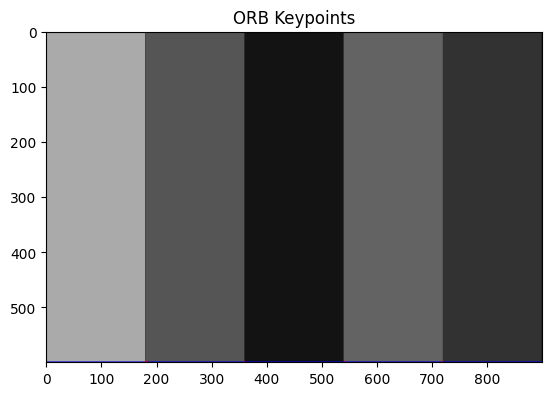

In [17]:
# Initialize the ORB detector
orb = cv2.ORB_create()

# Detect ORB features
keypoints, descriptors = orb.detectAndCompute(image, None)

# Draw keypoints
orb_image = cv2.drawKeypoints(image, keypoints, None, color=(0, 255, 0), flags=0)

# Display the image with keypoints
plt.imshow(cv2.cvtColor(orb_image, cv2.COLOR_BGR2RGB))
plt.title('ORB Keypoints')
plt.show()


# **3. Image Stitching and Panorama Creation**
**Homography and Warping**

* Homography is a transformation that maps points from one plane to another.

**Example:**



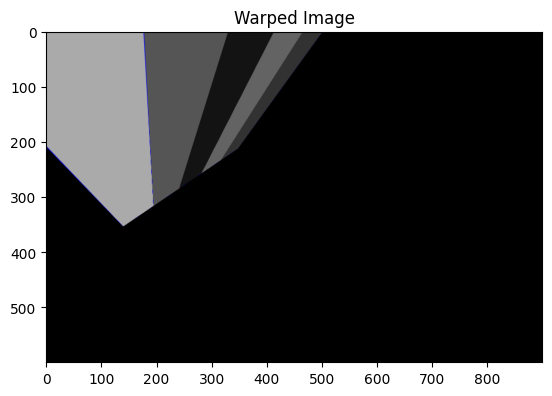

In [18]:
# Define points in the original and destination images
pts_src = np.array([[50,50], [200,50], [50,200], [200,200]])
pts_dst = np.array([[10,100], [200,50], [100,250], [200,200]])

# Calculate Homography
h, status = cv2.findHomography(pts_src, pts_dst)

# Warp source image to destination based on homography
im_dst = cv2.warpPerspective(image, h, (image.shape[1], image.shape[0]))

# Display warped image
plt.imshow(cv2.cvtColor(im_dst, cv2.COLOR_BGR2RGB))
plt.title('Warped Image')
plt.show()


**Image Stitching Pipeline**

* Image stitching combines multiple images to create a panorama.

**Example:**



In [23]:
# Initialize the Stitcher
stitcher = cv2.Stitcher_create()

# Read images - provide absolute paths or ensure images are in the same directory as the notebook
image1 = cv2.imread('/content/sample_data/example.jpg')  # Replace with actual path
image2 = cv2.imread('/content/sample_data/example1.jpg')  # Replace with actual path

# Check if images loaded successfully
if image1 is None:
    print("Error: Could not load image1.jpg. Check the file path.")
if image2 is None:
    print("Error: Could not load image2.jpg. Check the file path.")

# Stitch images
if image1 is not None and image2 is not None:  # Only stitch if images loaded successfully
    status, stitched_image = stitcher.stitch([image1, image2])

    if status == cv2.Stitcher_OK:
        # Display the stitched image
        plt.imshow(cv2.cvtColor(stitched_image, cv2.COLOR_BGR2RGB))
        plt.title('Stitched Image')
        plt.show()
    else:
        print("Error during stitching")

Error during stitching


**RANSAC Algorithm**

* RANSAC (Random Sample Consensus) is used to estimate parameters of a model by excluding outliers.

**Example:**

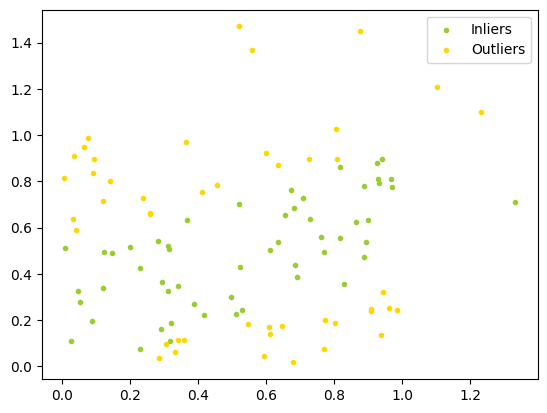

In [25]:
# Generate random data points
np.random.seed(42)
points = np.random.rand(100, 2)

# Add some outliers
points[:10] += 0.5

# Import the necessary module
from sklearn.linear_model import RANSACRegressor

# Fit a line using RANSAC
model_ransac = RANSACRegressor()
model_ransac.fit(points[:, 0].reshape(-1, 1), points[:, 1])

# Predict inliers and outliers
inliers = model_ransac.inlier_mask_
outliers = np.logical_not(inliers)

# Display inliers and outliers
plt.scatter(points[inliers, 0], points[inliers, 1], color='yellowgreen', marker='.', label='Inliers')
plt.scatter(points[outliers, 0], points[outliers, 1], color='gold', marker='.', label='Outliers')
plt.legend(loc='best')
plt.show()

# **4. Object Detection**
**Haar Cascades**

* Haar Cascades use pre-trained classifiers to detect objects, like faces.

**Example:**

In [27]:
# Load the pre-trained classifier for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load the image - Ensure the path is correct
image = cv2.imread('/path/to/your/image.jpg')  # Replace with the actual path

if image is None:
    print("Error: Could not load image. Check the file path.")
else:
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Check if the grayscale image is empty
    if gray.size == 0:
        print("Error: Grayscale image is empty. Check the conversion process.")
    else:
        # Detect faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # Draw rectangles around faces
        for (x, y, w, h) in faces:
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Display the result
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Face Detection')
        plt.show()

Error: Could not load image. Check the file path.


**HOG (Histogram of Oriented Gradients) and SVM**

* HOG combined with SVM is used for object detection, such as pedestrian detection.

**Example:**


In [29]:
# Initialize HOG descriptor and SVM detector
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Load the image - Ensure the path is correct
image = cv2.imread('/path/to/your/image.jpg')  # Replace with the actual path

if image is None:
    print("Error: Could not load image. Check the file path.")
else:
    # Detect people in the image
    (rects, weights) = hog.detectMultiScale(image, winStride=(4, 4), padding=(8, 8), scale=1.05)

    # Draw bounding boxes around detected people
    for (x, y, w, h) in rects:
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Display the result
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('HOG + SVM Object Detection')
    plt.show()

Error: Could not load image. Check the file path.


**YOLO (You Only Look Once)**

* YOLO is a real-time object detection system.

**Example:**


In [32]:
import numpy as np
import cv2

# Load YOLO model - Make sure these files are in the same directory as your notebook or provide the correct path.
net = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg')
layer_names = net.getLayerNames()
output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

# Load image - Replace 'example.jpg' with your image file
image = cv2.imread('/sample_data/example.jpg')
height, width, channels = image.shape

# Prepare the image for the YOLO model
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Extract bounding boxes, confidences, and class IDs
class_ids = []
confidences = []
boxes = []

for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply non-maxima suppression to remove redundant overlapping boxes
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes
for i in indices:
    i = i[0]
    box = boxes[i]
    x, y, w, h = box[0], box[1], box[2], box[3]
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    text = f"{class_ids[i]}: {confidences[i]:.2f}"
    cv2.putText(image, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display the result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('YOLO Object Detection')
plt.show()


**SSD (Single Shot MultiBox Detector)**

* SSD is another real-time object detection method.

**Example:**



In [35]:
# Load SSD model
# Ensure 'deploy.prototxt' and 'res10_300x300_ssd_iter_140000.caffemodel' are in the correct location.
# If they are not in the same directory as the notebook, provide the full path.
net = cv2.dnn.readNetFromCaffe('/path/to/deploy.prototxt', '/path/to/res10_300x300_ssd_iter_140000.caffemodel')

# Prepare the image for the SSD model
# Check if 'image' is loaded correctly. If not, load it before this step.
if image is None:
    print("Error: Image not loaded. Load the image before processing.")
else:
    blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

# Loop over the detections
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([width, height, width, height])
        (startX, startY, endX, endY) = box.astype("int")
        cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 2)

# Display the result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('SSD Object Detection')
plt.show()


# **5. Face Detection and Recognition**

**Face Detection with Haar Cascades and Dlib**

* Haar Cascades and Dlib are used for face detection.

**Example (Haar Cascades):**

In [37]:
# Load the pre-trained Haar Cascade classifier for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load image - Replace 'example.jpg' with your image file.
# Make sure the path is correct and the image exists.
image = cv2.imread('/sample_data/example.jpg')

# Check if image loading was successful
if image is None:
    print("Error: Could not load image. Check the file path.")
else:
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the result
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Face Detection with Haar Cascades')
    plt.show()

Error: Could not load image. Check the file path.


**Example (Dlib):**

In [39]:
import dlib
import cv2

# Load Dlib's pre-trained face detector
detector = dlib.get_frontal_face_detector()

# Load image - Replace 'example.jpg' with your image file.
# Make sure the path is correct and the image exists.
image = cv2.imread('/sample_data/example.jpg')

# Check if image loading was successful
if image is None:
    print("Error: Could not load image. Check the file path.")
else:
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = detector(gray)

    # Draw rectangles around faces
    for rect in faces:
        x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the result
    # Make sure you have imported matplotlib.pyplot as plt
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Face Detection with Dlib')
    plt.show()

Error: Could not load image. Check the file path.


**Face Landmarks Detection**

* Face landmarks detection identifies key facial features (e.g., eyes, nose, mouth).

**Example:**

In [41]:
# Load Dlib's shape predictor model
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

# Detect faces
faces = detector(gray)

# Detect landmarks for each face
for rect in faces:
    landmarks = predictor(gray, rect)
    for n in range(0, 68):
        x, y = landmarks.part(n).x, landmarks.part(n).y
        cv2.circle(image, (x, y), 2, (0, 255, 0), -1)

# Display the result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Face Landmarks Detection')
plt.show()


**Face Recognition with OpenCV and Dlib**

* Face recognition matches a face in an image to a database of known faces.

**Example:**

In [43]:
import face_recognition

# Load a sample picture and learn how to recognize it
known_image = face_recognition.load_image_file("known_person.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]

# Load an image with an unknown face
unknown_image = face_recognition.load_image_file("unknown_person.jpg")
unknown_encodings = face_recognition.face_encodings(unknown_image)

# Compare faces
results = face_recognition.compare_faces([known_encoding], unknown_encodings[0])

# Display the result
if results[0]:
    print("It's a match!")
else:
    print("Not a match!")
